In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import seaborn as sns
sns.set_theme(style='ticks', font_scale=2.3, palette=sns.color_palette(),)

import dafm.plots

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
benchmarked_runs = duckdb.sql("""
select
    testing_alt_id as alt_id,
    * exclude (testing_alt_id),
from '../sweeps/benchmark_*.csv'
""")
benchmarked_runs

┌──────────┬──────────────────┬────────────────────────────┬─────────────┐
│  alt_id  │ testing_rng_seed │        setting_name        │ filter_name │
│ varchar  │      int64       │          varchar           │   varchar   │
├──────────┼──────────────────┼────────────────────────────┼─────────────┤
│ 8yzsjn8k │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-F2P    │
│ c6kp9e26 │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-F2P    │
│ yrakk9c0 │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-F2P    │
│ nn5sqjxf │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-F2P    │
│ khq0ddu7 │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-OT     │
│ z5zo35bc │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-F2P    │
│ si0kbn1d │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-OT     │
│ t1cjk1gg │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-F2P    │
│ n7sjnsem │         97616566 │ KuramotoSivashinskyAtanObs │ EnFF-OT     │
│ nzndd7b5 │         9761

In [5]:
file_paths = dafm.plots.get_logged_metrics_file_paths(benchmarked_runs, file_path_format='~/out/revision-dafm/runs/{}/benchmark_filter.csv')
logged_metrics = dafm.plots.get_logged_metrics(benchmarked_runs, file_paths=file_paths)
logged_metrics

┌──────────┬─────────────────────┬────────────────────┬─────────────────┬────────────────────────┬──────────────────┬────────────┐
│  alt_id  │      elapsed_s      │     elapsed_ms     │ benchmark_iters │ benchmark_warmup_iters │ synchronize_cuda │ call_index │
│ varchar  │       double        │       double       │      int64      │         int64          │     boolean      │   int64    │
├──────────┼─────────────────────┼────────────────────┼─────────────────┼────────────────────────┼──────────────────┼────────────┤
│ 8yzsjn8k │ 0.24525879276916385 │ 245.25879276916385 │              50 │                      1 │ true             │          0 │
│ 8yzsjn8k │  0.2525704870931804 │ 252.57048709318042 │              50 │                      1 │ true             │          1 │
│ 8yzsjn8k │  0.2584606013260782 │  258.4606013260782 │              50 │                      1 │ true             │          2 │
│ 8yzsjn8k │ 0.25486329523846507 │ 254.86329523846507 │              50 │          

In [6]:
data_assimilation_settings = duckdb.sql(r"""
select DataAssimilationSetting, setting_name, dimension, dimension as dimension_label, from setting_kuramotosivashinsky_identity_obs
union
select DataAssimilationSetting, setting_name, 16 as dimension, '$16 \times 16$' as dimension_label, from setting_navierstokesdim16slow_identity_obs
union
select DataAssimilationSetting, setting_name, 64 as dimension, '$64 \times 64$' as dimension_label, from setting_navierstokesdim64slow_identity_obs
union
select DataAssimilationSetting, setting_name, 256 as dimension, '$256 \times 256$' as dimension_label, from setting_navierstokesdim256_identity_obs
""")
data_assimilation_settings

┌─────────────────────────┬───────────────────────────────────────┬───────────┬──────────────────┐
│ DataAssimilationSetting │             setting_name              │ dimension │ dimension_label  │
│          int64          │                varchar                │   int64   │     varchar      │
├─────────────────────────┼───────────────────────────────────────┼───────────┼──────────────────┤
│                     172 │ NavierStokesIdentityObsDim256         │       256 │ $256 \times 256$ │
│                     217 │ NavierStokesIdentityObsDim64Slow      │        64 │ $64 \times 64$   │
│                     111 │ KuramotoSivashinskyIdentityObsDim1024 │      1024 │ 1024             │
│                     115 │ KuramotoSivashinskyIdentityObsDim256  │       256 │ 256              │
│                     219 │ NavierStokesIdentityObsDim64Slow      │        64 │ $64 \times 64$   │
│                      55 │ KuramotoSivashinskyIdentityObsDim512  │       512 │ 512              │
│         

In [7]:
filters = duckdb.sql("""
select
    Filter, filter_name, null as sampling_time_step_count,
from to_plot_classical_filter
--where filter_name = 'EnKF-PO'
union
select
    Filter, filter_name, sampling_time_step_count,
from to_plot_generative_filter
where sampling_time_step_count = 5
""")
filters

┌────────┬─────────────┬──────────────────────────┐
│ Filter │ filter_name │ sampling_time_step_count │
│ int64  │   varchar   │          int64           │
├────────┼─────────────┼──────────────────────────┤
│  22888 │ LETKF       │                     NULL │
│  23509 │ LETKF       │                     NULL │
│  23555 │ LETKF       │                     NULL │
│  23598 │ LETKF       │                     NULL │
│  23574 │ LETKF       │                     NULL │
│  17910 │ EnKF-PO     │                     NULL │
│  17989 │ EnKF-PO     │                     NULL │
│  17966 │ EnKF-PO     │                     NULL │
│  18085 │ EnKF-PO     │                     NULL │
│  23587 │ LETKF       │                     NULL │
│    ·   │   ·         │                        · │
│    ·   │   ·         │                        · │
│    ·   │   ·         │                        · │
│  24746 │ EnFF-OT     │                        5 │
│  24878 │ EnFF-OT     │                        5 │
│  24902 │ E

In [8]:
to_plot = duckdb.sql("""
select
    alt_id,
    dimension as x,
    elapsed_ms / 1000 as y,
    filters.filter_name as hue,
    hue as style,
    benchmarked_runs.setting_name as row,
from logged_metrics
join benchmarked_runs using (alt_id)
join Conf using (alt_id)
join data_assimilation_settings using (DataAssimilationSetting)
join filters using (Filter)
""").pl()
to_plot

alt_id,x,y,hue,style,row
str,i64,f64,str,str,str
"""7xqst76q""",256,0.014305,"""EnFF-OT""","""EnFF-OT""","""KuramotoSivashinskyIdentityObs"""
"""skq0pv1a""",1024,0.009843,"""EnFF-OT""","""EnFF-OT""","""KuramotoSivashinskyIdentityObs"""
"""vpqs9t1e""",512,0.010205,"""EnFF-OT""","""EnFF-OT""","""KuramotoSivashinskyIdentityObs"""
"""5jbajdmq""",256,0.008884,"""EnSF""","""EnSF""","""KuramotoSivashinskyIdentityObs"""
"""ecbt6xhh""",1024,0.009481,"""EnSF""","""EnSF""","""KuramotoSivashinskyIdentityObs"""
…,…,…,…,…,…
"""3g1p0kxw""",16,0.001378,"""ESRF""","""ESRF""","""NavierStokesIdentityObs"""
"""zpll20zp""",64,27.79027,"""LETKF""","""LETKF""","""NavierStokesIdentityObs"""
"""97xbiwkg""",64,0.328243,"""EnKF-PO""","""EnKF-PO""","""NavierStokesIdentityObs"""


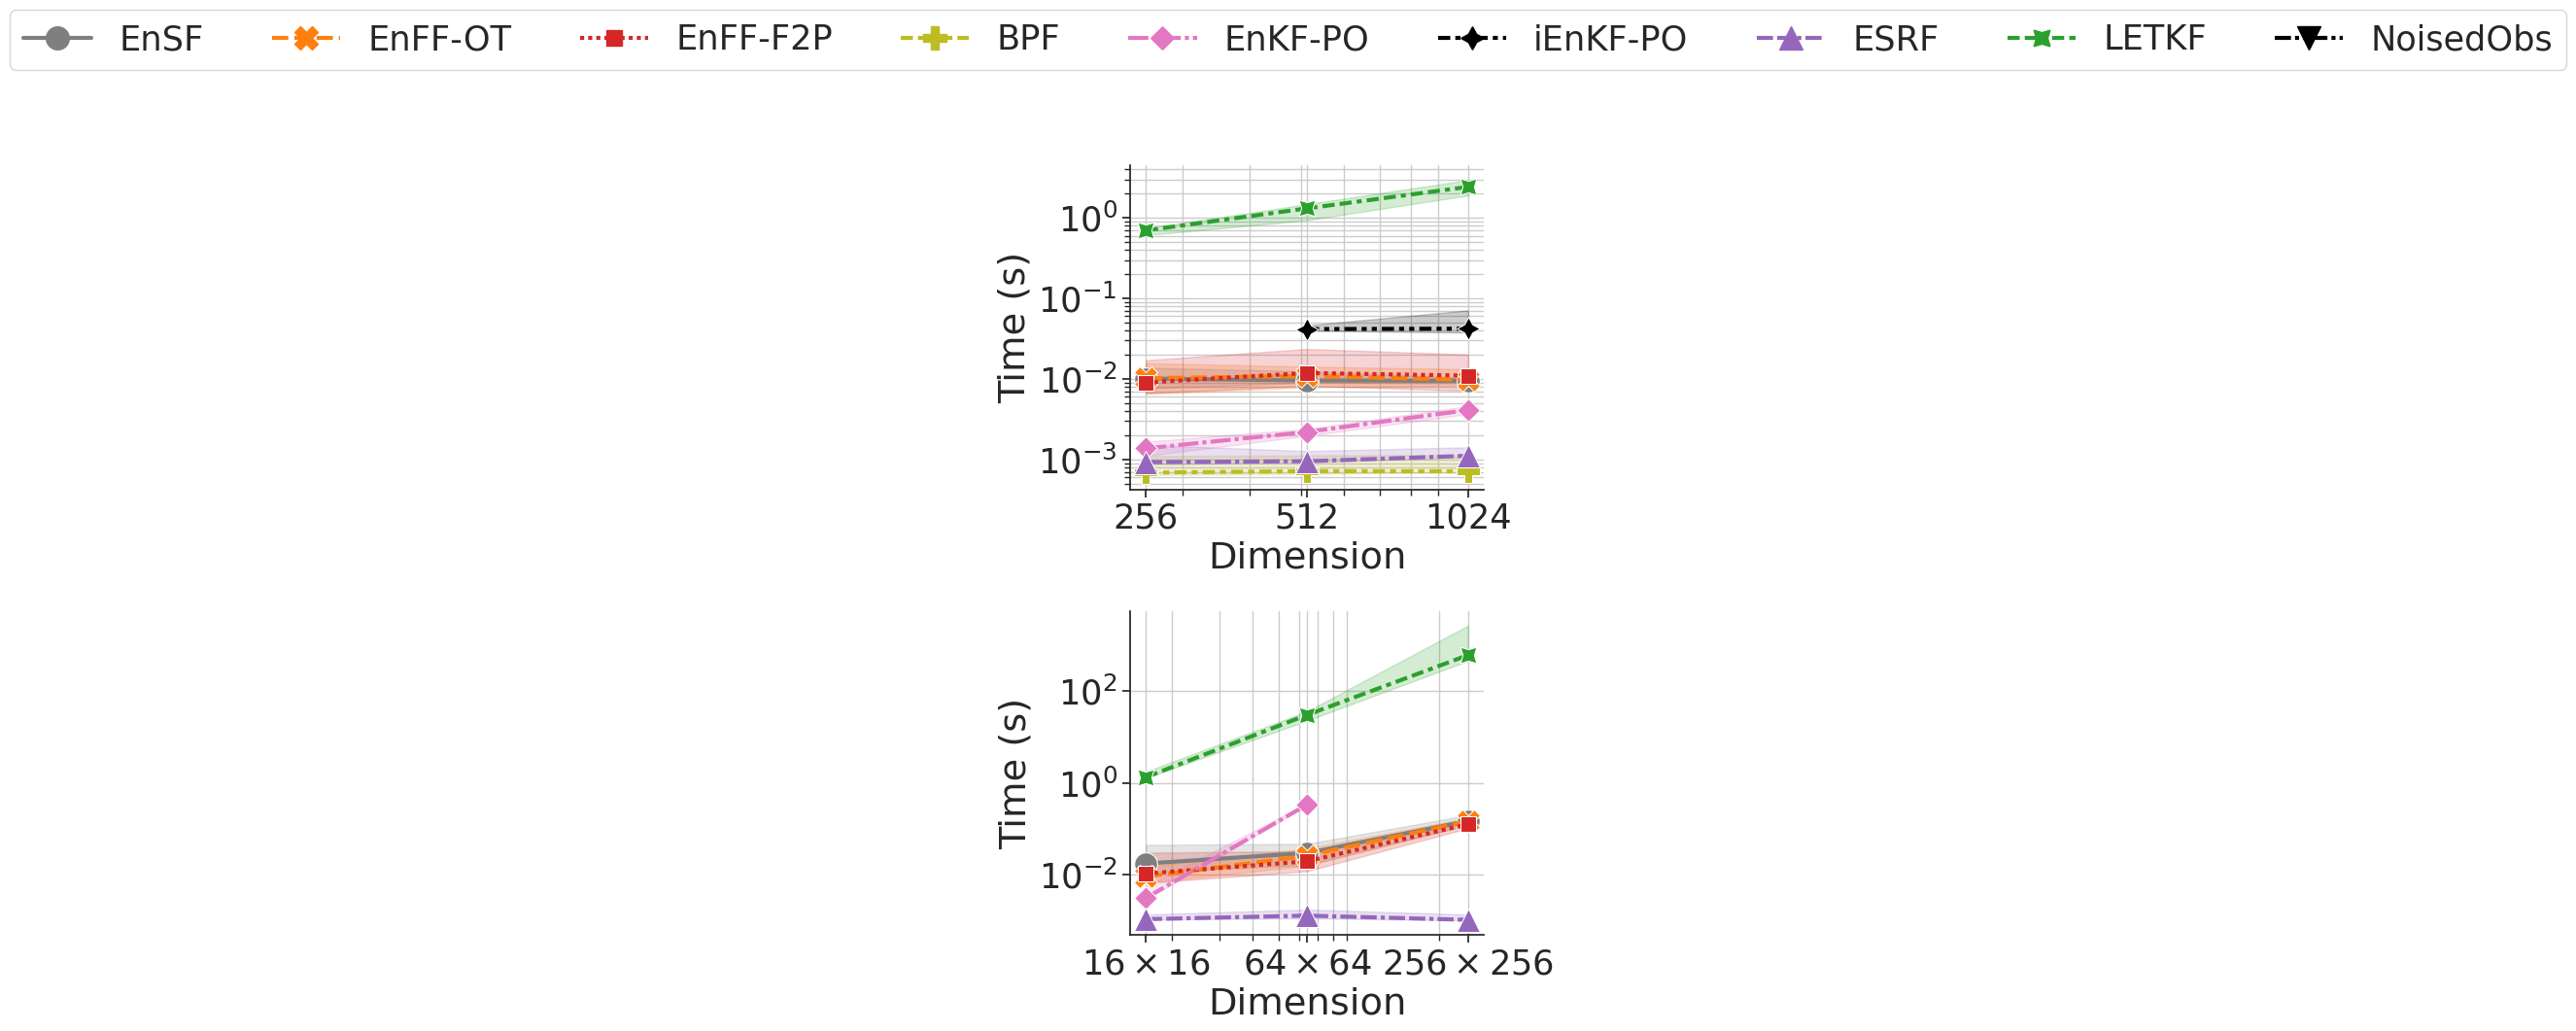

In [9]:
order = [k for k, v in sorted(dafm.plots.FILTER_ORDER.items(), key=lambda x: x[1])]
plot = (
    sns.relplot(
        kind='line',
        estimator='mean',
        errorbar=('pi', 100),
        data=to_plot.to_pandas(),
        **{k: k if k != 'style' else 'hue' for k in to_plot.columns if k != 'alt_id'},
        hue_order=order,
        style_order=order,
        palette=dafm.plots.FILTER_PALETTE,
        markers=True,
        linewidth=3,
        markersize=17,
        aspect=1.3,
        facet_kws=dict(
            sharex=False,
            sharey=False,
        ),
    )
    .set_titles('')
    .set(
        xscale='log',
        xlabel='Dimension',
        yscale='log',
        ylabel='Time (s)',
        # xticks=to_plot['x'].unique(),
        # xticklabels=to_plot['x'].unique(),
        # xticklabels=[rf'${x} \times {x}$' for x in to_plot['x'].unique()],
    )
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot.facet_data():
    ax = plot.axes[row, col]
    ax.grid()
    ax.grid(which='minor')
    ax.tick_params(axis='both', which='minor', labelbottom=False)
    c = plot.row_names[row]
    if 'KuramotoSivashinskyIdentityObs' in c:
        xticks = to_plot.filter(row='KuramotoSivashinskyIdentityObs')['x'].unique()
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks)
    elif 'NavierStokesIdentityObs' in c:
        xticks = to_plot.filter(row='NavierStokesIdentityObs')['x'].unique()
        ax.set_xticks(xticks)
        ax.set_xticklabels([rf'${x} \times {x}$' for x in xticks])

In [10]:
dafm.plots.save_all_subfigures(plot, 'BenchmarkTiming')